In [1]:
import pandas as pd
import os

files = os.listdir("../data/raw")
print(files)

['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [2]:
tables = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

dfs = {}
for name, filename in tables.items():
    path = f"../data/raw/{filename}"
    df = pd.read_csv(path)
    dfs[name] = df
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print("nulls:\n", df.isnull().sum()[df.isnull().sum() > 0])
    print("duplicate rows:", df.duplicated().sum())


=== orders ===
shape: (99441, 8)
columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
nulls:
 order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
duplicate rows: 0

=== order_items ===
shape: (112650, 7)
columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
nulls:
 Series([], dtype: int64)
duplicate rows: 0

=== customers ===
shape: (99441, 5)
columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
nulls:
 Series([], dtype: int64)
duplicate rows: 0

=== products ===
shape: (32951, 9)
columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product

In [3]:
print(dfs["orders"]["order_status"].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [4]:
print(dfs["reviews"]["review_id"].duplicated().sum())

814


In [5]:
dupe_ids = dfs["reviews"][dfs["reviews"]["review_id"].duplicated(keep=False)]
dupe_ids.sort_values("review_id").head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

DB_USER = "postgres"
DB_PASSWORD = "1234"   
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "olist_retail"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

query = """
SELECT
    DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
    COUNT(DISTINCT o.order_id) AS num_orders,
    SUM(oi.price) AS total_revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY month
ORDER BY month;
"""

sales_trend = pd.read_sql(query, engine)
sales_trend.head()

,month,num_orders,total_revenue
0,2016-09-01,1,134.97
1,2016-10-01,265,40325.11
2,2016-12-01,1,10.90
3,2017-01-01,750,111798.36
4,2017-02-01,1653,234223.40


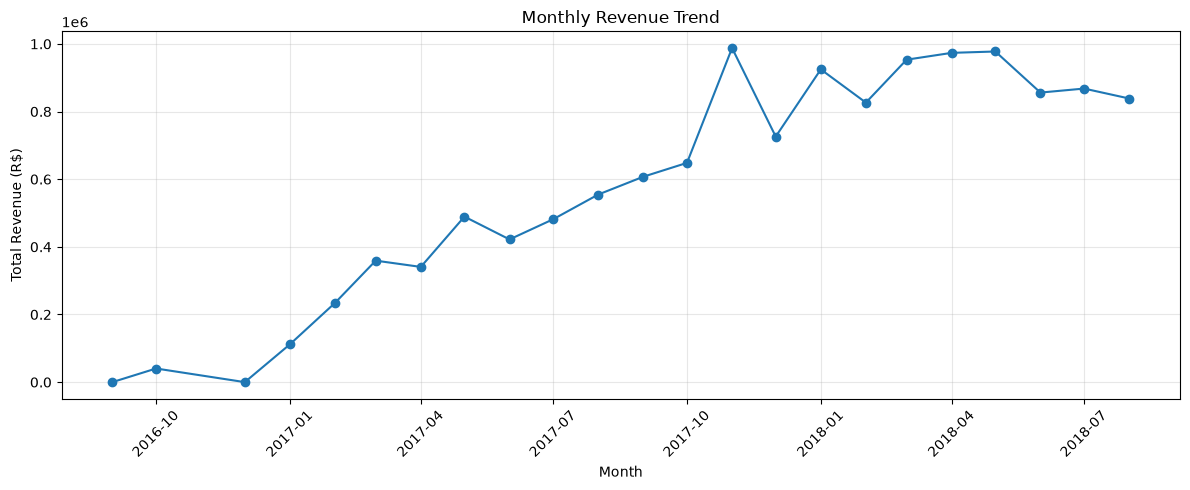

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(sales_trend["month"], sales_trend["total_revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (R$)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
query2 = """
SELECT
    r.review_score,
    COUNT(*) AS num_orders,
    ROUND(AVG(EXTRACT(DAY FROM (o.order_delivered_customer_date - o.order_purchase_timestamp))), 1) AS avg_delivery_days
FROM orders o
JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY r.review_score
ORDER BY r.review_score;
"""

delivery_reviews = pd.read_sql(query2, engine)
delivery_reviews

,review_score,num_orders,avg_delivery_days
0,1,9405,20.8
1,2,2941,16.2
2,3,7961,13.8
3,4,18987,11.8
4,5,57059,10.2


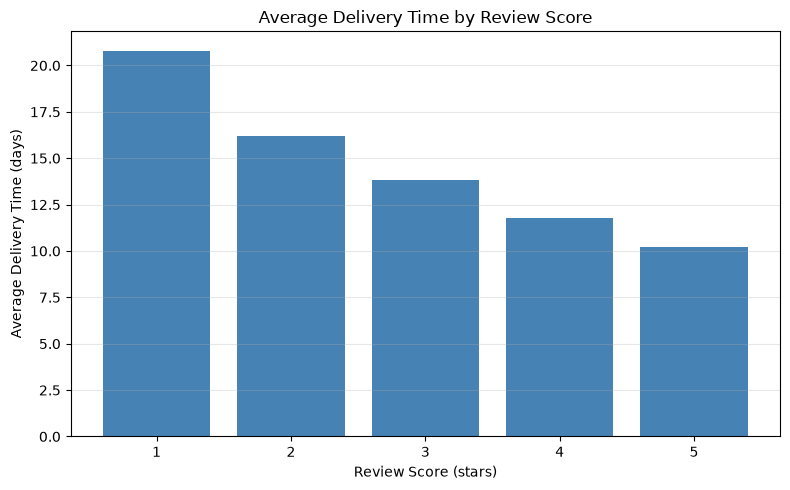

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(delivery_reviews["review_score"], delivery_reviews["avg_delivery_days"], color="steelblue")
plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score (stars)")
plt.ylabel("Average Delivery Time (days)")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
query3 = """
SELECT
    s.seller_id,
    s.seller_state,
    COUNT(DISTINCT oi.order_id) AS num_orders,
    SUM(oi.price) AS total_revenue,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    ROUND(AVG(EXTRACT(DAY FROM (o.order_delivered_customer_date - o.order_purchase_timestamp))), 1) AS avg_delivery_days
FROM sellers s
JOIN order_items oi ON s.seller_id = oi.seller_id
JOIN orders o ON oi.order_id = o.order_id
LEFT JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
GROUP BY s.seller_id, s.seller_state
HAVING COUNT(DISTINCT oi.order_id) >= 20
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_sellers = pd.read_sql(query3, engine)
top_sellers

,seller_id,seller_state,num_orders,total_revenue,avg_review_score,avg_delivery_days
0,4869f7a5dfa277a7dca6462dcf3b52b2,SP,1124,226987.93,4.14,14.5
1,53243585a1d6dc2643021fd1853d8905,BA,348,217940.44,4.13,12.9
2,4a3ca9315b744ce9f8e9374361493884,SP,1772,199408.32,3.83,13.9
3,fa1c13f2614d7b5c4749cbc52fecda94,SP,578,190917.14,4.37,12.8
4,7c67e1448b00f6e969d365cea6b010ab,SP,973,188063.83,3.35,21.9
5,7e93a43ef30c4f03f38b393420bc753a,SP,319,165981.49,4.36,10.8
6,da8622b14eb17ae2831f4ac5b9dab84a,SP,1311,162303.67,4.08,10.7
7,7a67c85e85bb2ce8582c35f2203ad736,SP,1145,140238.65,4.27,10.7
8,1025f0e2d44d7041d6cf58b6550e0bfa,SP,910,139720.16,3.87,11.5
9,955fee9216a65b617aa5c0531780ce60,SP,1261,131906.71,4.09,10.3


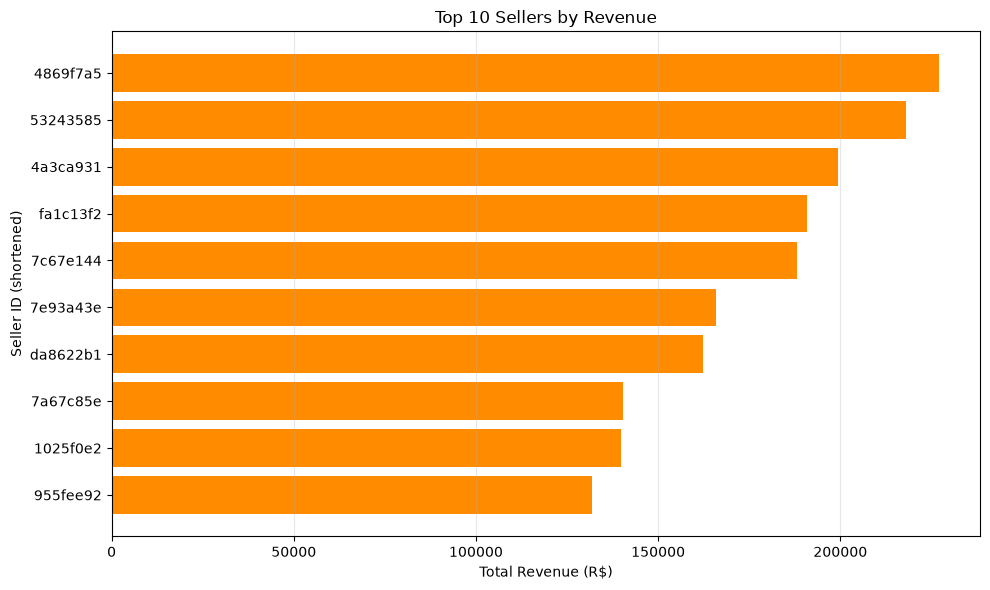

In [7]:
# shorten seller_id just for readable chart labels
top_sellers["short_id"] = top_sellers["seller_id"].str[:8]

plt.figure(figsize=(10, 6))
plt.barh(top_sellers["short_id"], top_sellers["total_revenue"], color="darkorange")
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Seller ID (shortened)")
plt.gca().invert_yaxis()  # highest revenue at the top
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
query4 = """
SELECT
    CASE
        WHEN order_count = 1 THEN 'One-time buyer'
        ELSE 'Repeat buyer'
    END AS customer_type,
    COUNT(*) AS num_customers
FROM (
    SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
) AS customer_orders
GROUP BY customer_type;
"""

customer_types = pd.read_sql(query4, engine)
customer_types

,customer_type,num_customers
0,Repeat buyer,2801
1,One-time buyer,90557


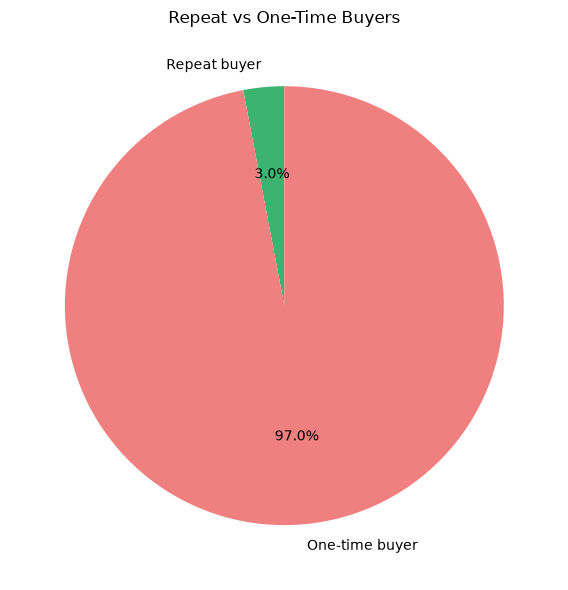

In [9]:
plt.figure(figsize=(6, 6))
plt.pie(
    customer_types["num_customers"],
    labels=customer_types["customer_type"],
    autopct="%1.1f%%",
    colors=["mediumseagreen", "lightcoral"],
    startangle=90
)
plt.title("Repeat vs One-Time Buyers")
plt.tight_layout()
plt.show()